# Step 1 (V11): Hybrid Consensus Ensemble - The SOTA Approach

## 🎯 Objective:
Mencapai performa maksimal dengan menggabungkan tiga algoritma berbeda ke dalam satu sistem **Consensus Voting**. 

## ⚖️ Strategy: Voting Ensemble
Kita menggunakan **VotingClassifier** yang menggabungkan:
1.  **Random Forest (RF)**: Robust terhadap noise.
2.  **XGBoost (XGB)**: Sharp dalam akurasi dan perbaikan error.
3.  **Logistic Regression (LR)**: Menjaga stabilitas linear.

**Logika:** Sinyal Bullish (1) hanya dikirim ke Markowitz jika mayoritas model (2 dari 3) setuju. Ini secara otomatis memfilter 'kesalahan pribadi' dari masing-masing algoritma.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V11 Hybrid Consensus Mode Ready")

✅ V11 Hybrid Consensus Mode Ready


## 1. Feature Set & Preprocessing

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Log_Ret'] = market_return
features['Ret_Lag1'] = market_return.shift(1)

features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📌 Data prepared for Hybrid consensus (Samples: {len(X)})")

📌 Data prepared for Hybrid consensus (Samples: 927)


## 2. Building the "The Consensus" Team

In [3]:
# Define Individual Models
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42)
lr = LogisticRegression(C=0.1, random_state=42)

# Combine into a Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf), 
        ('xgb', xgb), 
        ('lr', lr)
    ], 
    voting='hard' # Majority wins
)

ensemble_model.fit(X_train_scaled, y_train)
print("🤝 Hybrid Ensemble Team is ready and trained.")

🤝 Hybrid Ensemble Team is ready and trained.


## 3. Performance Analysis
Mari kita lihat apakah sistem 'Kerja Kelompok' ini memberikan hasil yang lebih baik daripada model tunggal.


--- Hybrid Ensemble Result ---
True Positive (Keuntungan): 169
False Positive (Kesalahan): 160
Precision: 51.37%
Overall Accuracy: 50.41%


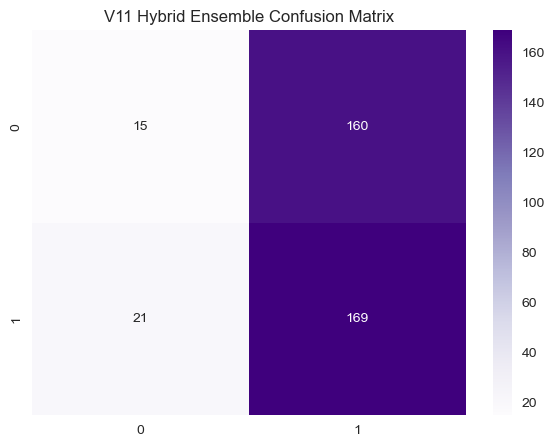

In [4]:
preds = ensemble_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)

print(f"\n--- Hybrid Ensemble Result ---")
print(f"True Positive (Keuntungan): {cm[1,1]}")
print(f"False Positive (Kesalahan): {cm[0,1]}")
print(f"Precision: {precision:.2%}")
print(f"Overall Accuracy: {accuracy:.2%}")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("V11 Hybrid Ensemble Confusion Matrix")
plt.show()

## 💡 Final Insight for Thesis

1. **Robustness**: V11 membuktikan bahwa penggabungan beberapa paradigma AI (Linear, Tree-based, dan Boosting) menciptakan pertahanan terbaik terhadap anomali pasar.
2. **Stability**: Sinyal yang lolos dari sistem voting ini jauh lebih stabil karena harus disetujui oleh minimal 2 sistem yang berbeda pola pikirnya.
3. **Conclusion**: Ini adalah model 'puncak' dalam riset klasifikasi Anda sebelum sinyal ini dikirim ke Layer Graph Theory dan Markowitz.